<a href="https://colab.research.google.com/github/marcusestevan/Aurora-Siger-Mission/blob/main/relatorio-aurora-siger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Missão Aurora Siger
### Relatório Operacional de Pré-Decolagem — Fase 1

**Autor:** Marcus Estevan Bandeira  
**Turma:** 1CCOB | RM573445@fiap.com.br  

**Data:** Março de 2026

---

## Introdução

14 de julho de 2035. Base de lançamento da **SpaceXG**, na Fazenda Xurupitas, Tocantins. Eram 4h47 da manhã e o café já tinha assumido o comando da sala de controle.

Na plataforma, a nave **Aurora Siger** aguardava a partida. **73 metros de altura, tanques cheios, 6 tripulantes a bordo e muita oração.** Destino: Marte. Tempo estimado: 60 dias.

No papel, seria uma missão exemplar. Na prática só deus sabe.

Ao longo da viagem, a tripulação enfrentou oscilações de comunicação com um padrão difícil de explicar, uma parada de emergência na Estação Espacial do Seu Zé para reabastecimento, um desvio de asteroide que consumiu combustível fora do plano e, como se isso ainda fosse pouco, o desaparecimento do astronauta Severino durante um reparo externo. Ele reapareceu na base de pouso em Marte sem qualquer lembrança do que ocorreu entre os dias 44 e 59, um detalhe operacional que costuma chamar atenção.

Este relatório analisa a telemetria da missão e organiza os principais eventos a partir dos dados coletados. Os números são objetivos, a missão, nem tanto.

---

**Estrutura:**
- **1.1** Organização e descrição da telemetria
- **1.2** Algoritmo de verificação
- **1.3** Script em Python
- **1.4** Análise energética
- **1.5** Análise assistida por IA
- **1.6** Reflexão crítica

---

---
## 1.1 Organização e Descrição da Telemetria

A telemetria da Aurora Siger monitora 17 sensores em tempo real. São 120 leituras distribuídas ao longo de 60 dias — da decolagem em Xurupitas até a chegada em Marte.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load telemetry data
df = pd.read_csv('telemetria_nave_spacexg_marte_relatorio.csv')

print("Total records:", len(df))
print("Total columns:", len(df.columns))
print()

print("Monitored sensors:")
for column in df.columns:
    print(" -", column)

Total records: 120
Total columns: 17

Monitored sensors:
 - timestamp_utc
 - mission_day
 - vehicle
 - mission
 - phase
 - temp_internal_c
 - temp_external_c
 - structural_integrity_0_1
 - energy_level_pct
 - fuel_tank_pressure_bar
 - oxidizer_tank_pressure_bar
 - propulsion_status
 - life_support_status
 - navigation_status
 - communications_status
 - thermal_control_status
 - overall_alert


In [3]:
# First 10 mission readings
df.head(10)


,timestamp_utc,mission_day,vehicle,mission,phase,temp_internal_c,temp_external_c,structural_integrity_0_1,energy_level_pct,fuel_tank_pressure_bar,oxidizer_tank_pressure_bar,propulsion_status,life_support_status,navigation_status,communications_status,thermal_control_status,overall_alert
0,2035-07-14T07:47:00Z,0.0,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,21.2,-137.8,1,97.0,246.9,262.9,OK,OK,OK,OK,OK,Nominal
1,2035-07-14T19:47:00Z,0.5,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,22.8,-133.1,1,96.8,247.8,260.2,OK,OK,OK,OK,OK,Nominal
2,2035-07-15T07:47:00Z,1.0,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,22.3,-136.5,1,96.4,247.0,262.7,OK,OK,OK,OK,OK,Nominal
3,2035-07-15T19:47:00Z,1.5,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,22.0,-127.4,1,97.5,249.6,260.2,OK,OK,OK,OK,OK,Nominal
4,2035-07-16T07:47:00Z,2.0,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,22.9,-119.5,1,96.7,247.0,264.1,OK,OK,OK,OK,OK,Nominal
5,2035-07-16T19:47:00Z,2.5,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,22.1,-123.6,1,95.9,249.8,262.7,OK,OK,OK,OK,OK,Nominal
6,2035-07-17T07:47:00Z,3.0,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,23.2,-112.9,1,97.6,250.3,261.7,OK,OK,OK,OK,OK,Nominal
7,2035-07-17T19:47:00Z,3.5,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,23.5,-114.1,1,97.8,249.8,262.5,OK,OK,OK,OK,OK,Nominal
8,2035-07-18T07:47:00Z,4.0,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,22.3,-109.1,1,95.9,247.3,260.4,OK,OK,OK,OK,OK,Nominal
9,2035-07-18T19:47:00Z,4.5,SpaceXG Interplanetary Transporter,Mars Colonization Mission (simulated),Launch & Earth Departure,22.5,-114.6,1,95.6,248.4,261.4,OK,OK,OK,OK,OK,Nominal


In [4]:
# Mission phases
print("Mission phases:")
print()
phase_counts = df['phase'].value_counts()
for phase in phase_counts.index:
    print(" ", phase, "->", phase_counts[phase], "readings")


Mission phases:

  Deep Space Transit -> 84 readings
  Mars Approach -> 18 readings
  Launch & Earth Departure -> 12 readings
  Mars Orbit Insertion -> 4 readings
  Mars Landing -> 1 readings
  Mars Surface Operations -> 1 readings


In [5]:
# Statistical summary
df[['temp_internal_c', 'temp_external_c', 'energy_level_pct',
    'fuel_tank_pressure_bar', 'oxidizer_tank_pressure_bar']].describe()


,temp_internal_c,temp_external_c,energy_level_pct,fuel_tank_pressure_bar,oxidizer_tank_pressure_bar
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,22.002500,-118.381667,73.600000,222.123333,233.501667
std,1.181543,25.041901,13.943186,16.040310,18.081106
min,19.900000,-163.000000,46.200000,190.200000,205.900000
25%,20.975000,-139.500000,61.300000,209.750000,215.675000
50%,22.050000,-116.600000,72.950000,225.100000,234.250000
75%,22.925000,-98.775000,84.300000,231.400000,246.325000
max,24.300000,-71.600000,97.800000,250.300000,264.100000


### Interpretação dos dados

**Temperatura interna:** permaneceu estável entre 19°C e 24°C durante toda a missão. O sistema térmico fez exatamente o que se espera de um bom sistema: funcionou.

**Energia:** caiu de 97% para 46% ao longo de 60 dias. A redução foi gradual, mas os momentos críticos deixaram marcas claras no consumo.

**Pressão dos tanques:** apresentou queda progressiva compatível com as correções de trajetória. Uma dessas correções, vale notar, não constava exatamente no roteiro original.

**Integridade estrutural:** manteve valor 1 em quase toda a missão. A exceção do dia 44 bastou para lembrar que, em sistemas críticos, a paz costuma durar até o primeiro susto.

Vamos aos eventos:

In [6]:
# Off-nominal events
alerts = df[df['overall_alert'] != 'Nominal']

print("Off-nominal events:", len(alerts), "out of", len(df), "readings")
print()

for i in alerts.index:
    day = alerts.loc[i, 'mission_day']
    phase = alerts.loc[i, 'phase']
    alert = alerts.loc[i, 'overall_alert']
    print("  Day", day, "|", phase, "|", alert)


Off-nominal events: 7 out of 120 readings

  Day 9.0 | Deep Space Transit | Communications fluctuation
  Day 16.5 | Deep Space Transit | Thermal loop adjustment
  Day 17.0 | Deep Space Transit | Thermal loop adjustment
  Day 28.5 | Deep Space Transit | Communications fluctuation
  Day 36.0 | Deep Space Transit | Navigation recalibration
  Day 44.0 | Deep Space Transit | Micrometeoroid impact inspection
  Day 45.0 | Deep Space Transit | Pre-insertion engine conditioning


### Diário de Bordo

---

#### Dia 9 — O primeiro sinal

A comunicação com a Terra ficou degradada por algumas horas. Em missões de longa distância, isso não seria alarmante por si só. O problema é que o técnico de comunicação, Ademar, identificou um padrão recorrente no ruído, algo que não correspondia a nenhum satélite catalogado.

Ele reportou o achado. O engenheiro-chefe Ubirajara examinou os dados e atribuiu o caso a interferência interna. Ademar não insistiu, mas algo não soava certo.

O log resumiu o episódio em duas palavras: *"Communications fluctuation"*.

---

#### Dias 16.5 e 17 — Ajuste térmico

O loop de controle térmico precisou ser recalibrado. Considerando a alternância entre extremos térmicos no ambiente externo, a correção era necessária. A temperatura interna oscilou levemente, mas permaneceu dentro dos parâmetros operacionais.

---

#### Dia 28.5 — O sinal voltou

A comunicação degradou novamente. O comportamento lembrava o do dia 9. Ademar abriu o caderno, comparou as anotações e registrou: *"Intervalo de 19,5 dias. Há recorrência, mas ainda não dá para chamar isso de periodicidade estável."*

Ao mostrar isso ao engenheiro-chefe, recebeu uma resposta breve, técnica e universalmente reconhecida: "Você já sabe o que fazer”.

---

#### Dia 36 — Estação Espacial do Seu Zé

A navegação entrou em recalibração após uma parada não programada na **Estação Espacial do Seu Zé**, um módulo orbital auxiliar cujo apelido já tinha vencido qualquer nome oficial.

O motivo foi simples: a energia estava caindo mais rápido do que o previsto. A estação oferecia suporte para recarga solar, e o procedimento permitiu recuperar margem operacional. Em termos técnicos, foi uma manobra corretiva. Em termos honestos, foi o momento em que a missão admitiu que improvisar também é método.

---

#### Dia 44 — O ponto de ruptura

A integridade estrutural caiu para zero em uma leitura. Ao mesmo tempo, dois subsistemas críticos ficaram degradados. O diagnóstico aponta impacto de micrometeorito e necessidade de reparo emergencial.

Foi durante essa sequência que o astronauta Severino saiu para atividade extraveicular e foi dado como desaparecido após a perda de sinal.

Esse foi o momento em que a anomalia deixou de ser evento pontual e passou a reorganizar a dinâmica da missão.

---

#### Dias 45 e 46 — Silêncio operacional

Com a propulsão em **STANDBY**, a nave passou cerca de 24 horas sem plena capacidade de manobra. Era o tipo de intervalo em que qualquer engenheiro olha para os gráficos em silêncio e começa a fazer promessas técnicas para entidades não regulamentadas pela NASA.

---

#### Dia 59 — Marte

A Aurora Siger pousou.

O saldo oficial incluía comunicação intermitente, consumo energético acima do previsto, danos estruturais reparados em voo e o desaparecimento temporário de um astronauta.

Severino foi encontrado na base de pouso. Sem traje. Sem lesões. Sem memória.

A telemetria não explica tudo. Felizmente, ela nunca prometeu explicar.

---
## 1.2 Algoritmo de Verificação

Quando a missão envolve asteroide, falha estrutural e astronauta sumindo no espaço, confiar apenas no “parece tudo certo” deixa de ser método e passa a ser fé. Por isso, a checagem precisa ser automatizada.

### Faixas seguras

| Parâmetro | Condição segura |
|:---|:---|
| Temperatura interna | 18°C a 28°C |
| Integridade estrutural | = 1 |
| Energia | > 40% |
| Pressão combustível | > 180 bar |
| Pressão oxidante | > 200 bar |
| Subsistemas | Todos "OK" |

### Pseudocódigo

```
INÍCIO

  Carregar telemetria do CSV

  PARA CADA leitura:
    falhas = lista vazia

    SE temperatura fora de 18-28: registrar falha
    SE integridade != 1: registrar falha
    SE energia < 40%: registrar falha
    SE pressão combustível < 180: registrar falha
    SE pressão oxidante < 200: registrar falha
    SE algum subsistema != OK: registrar falha

    SE sem falhas: PRONTO PARA DECOLAR
    SE tem falha: DECOLAGEM ABORTADA

FIM
```

### Fluxograma

```
          [INÍCIO]
             |
             v
       [Carregar CSV]
             |
             v
    [Próxima leitura] ←←←←←←+
             |               |
             v               |
    [Checar temperatura]     |
    [Checar integridade]     |
    [Checar energia]         |
    [Checar pressões]        |
    [Checar subsistemas]     |
             |               |
             v               |
      [Alguma falha?]        |
        /       \            |
      NÃO       SIM          |
       |         |           |
   [PRONTO]  [ABORTADA]      |
       |         |           |
       +---------+-----------+
            |
            v
          [FIM]
```

---
## 1.3 Script em Python

In [9]:
# Check each reading with severity classification
# Severity: NOMINAL < WARNING < CRITICAL < CATASTROPHIC

decisions = []
reasons = []
severities = []

for i in range(len(df)):
    failures = []
    max_severity = 0  # 0=NOMINAL, 1=WARNING, 2=CRITICAL, 3=CATASTROPHIC

    # Temperature check (WARNING if slightly out, CRITICAL if far out)
    temp = df.loc[i, 'temp_internal_c']
    if temp < 18 or temp > 28:
        failures.append("Internal temperature out of range: " + str(temp) + "°C")
        if 15 < temp < 32:
            max_severity = max(max_severity, 1)
        else:
            max_severity = max(max_severity, 2)

    # Structural integrity (CATASTROPHIC if compromised)
    integrity = df.loc[i, 'structural_integrity_0_1']
    if integrity != 1:
        failures.append("Structural integrity compromised")
        max_severity = 3

    # Energy check (WARNING < 50%, CRITICAL < 40%)
    energy = df.loc[i, 'energy_level_pct']
    if energy < 40:
        failures.append("Low energy: " + str(energy) + "%")
        max_severity = max(max_severity, 2)

    # Pressure checks (CRITICAL)
    fuel = df.loc[i, 'fuel_tank_pressure_bar']
    if fuel < 180:
        failures.append("Low fuel pressure: " + str(fuel) + " bar")
        max_severity = max(max_severity, 2)

    oxidizer = df.loc[i, 'oxidizer_tank_pressure_bar']
    if oxidizer < 200:
        failures.append("Low oxidizer pressure: " + str(oxidizer) + " bar")
        max_severity = max(max_severity, 2)

    # Subsystem checks (1 degraded = WARNING, 2+ = CRITICAL)
    subsystem_issues = 0
    for sys_col, sys_name in [
        ('propulsion_status', 'Propulsion'),
        ('life_support_status', 'Life support'),
        ('navigation_status', 'Navigation'),
        ('communications_status', 'Communications'),
        ('thermal_control_status', 'Thermal control')
    ]:
        if df.loc[i, sys_col] != 'OK':
            failures.append(sys_name + ": " + df.loc[i, sys_col])
            subsystem_issues += 1

    if subsystem_issues >= 2:
        max_severity = max(max_severity, 2)
    elif subsystem_issues == 1:
        max_severity = max(max_severity, 1)

    severity_labels = {0: "NOMINAL", 1: "WARNING", 2: "CRITICAL", 3: "CATASTROPHIC"}

    if len(failures) == 0:
        decisions.append("READY")
        reasons.append("")
        severities.append("NOMINAL")
    else:
        decisions.append("FLAGGED")
        reasons.append(" | ".join(failures))
        severities.append(severity_labels[max_severity])

df['decision'] = decisions
df['reason'] = reasons
df['severity'] = severities

print("CHECK RESULT")
print("Readings analyzed:", len(df))
print("READY:", decisions.count("READY"))
print("FLAGGED:", decisions.count("FLAGGED"))
print()
print("Severity breakdown:")
for level in ["WARNING", "CRITICAL", "CATASTROPHIC"]:
    count = severities.count(level)
    if count > 0:
        print(f"  {level}: {count}")

CHECK RESULT
Readings analyzed: 120
READY: 111
FLAGGED: 9

Severity breakdown:
  CATASTROPHIC: 1


In [11]:
# Moments when the system detected a problem — sorted by severity
flagged = df[df['decision'] == 'FLAGGED']

severity_order = {"CATASTROPHIC": 0, "CRITICAL": 1, "WARNING": 2}
flagged_sorted = flagged.copy()
flagged_sorted['sev_order'] = flagged_sorted['severity'].map(severity_order)
flagged_sorted = flagged_sorted.sort_values(['sev_order', 'mission_day'])

if len(flagged_sorted) > 0:
    print("Flagged readings (by severity):")
    print()
    for i in flagged_sorted.index:
        day = df.loc[i, 'mission_day']
        severity = df.loc[i, 'severity']
        reason = df.loc[i, 'reason']
        if severity == "CATASTROPHIC":
            marker = "!!!"
        elif severity == "CRITICAL":
            marker = " !!"
        else:
            marker = "  !"
        print(f"  {marker} Day {day} [{severity}] -> {reason}")
else:
    print("No problematic readings found in the recorded data.")

Flagged readings (by severity):

  !!! Day 44.0 [CATASTROPHIC] -> Structural integrity compromised | Communications: DEGRADED | Thermal control: DEGRADED
    ! Day 9.0 [WARNING] -> Communications: DEGRADED
    ! Day 16.5 [WARNING] -> Thermal control: DEGRADED
    ! Day 17.0 [WARNING] -> Thermal control: DEGRADED
    ! Day 28.5 [WARNING] -> Communications: DEGRADED
    ! Day 36.0 [WARNING] -> Navigation: CALIBRATING
    ! Day 45.0 [WARNING] -> Propulsion: STANDBY
    ! Day 45.5 [WARNING] -> Propulsion: STANDBY
    ! Day 46.0 [WARNING] -> Propulsion: STANDBY


In [12]:
# Launch phase verification
launch = df[df['phase'] == 'Launch & Earth Departure']

print("PRE-LAUNCH CHECK")
print()
print("Launch readings:", len(launch))
print()
print("Internal temp.:", launch['temp_internal_c'].min(), "to", launch['temp_internal_c'].max(), "°C")
print("Energy:", launch['energy_level_pct'].min(), "to", launch['energy_level_pct'].max(), "%")
print("Fuel pressure:", launch['fuel_tank_pressure_bar'].min(), "to", launch['fuel_tank_pressure_bar'].max(), "bar")
print("Oxidizer pressure:", launch['oxidizer_tank_pressure_bar'].min(), "to", launch['oxidizer_tank_pressure_bar'].max(), "bar")

integrity_min = int(launch['structural_integrity_0_1'].min())
if integrity_min == 0:
    print()
    print("=" * 60)
    print("  ALERT — STRUCTURAL INTEGRITY = 0 DURING LAUNCH PHASE")
    print("  IMMEDIATE INSPECTION REQUIRED")
    print("=" * 60)
else:
    print("Integrity:", integrity_min, "(nominal)")

print()
issues = launch[launch['decision'] == 'FLAGGED']
if len(issues) == 0:
    print("RESULT: READY FOR LAUNCH")
else:
    print("RESULT: LAUNCH REQUIRES REVIEW")
    for i in issues.index:
        print(f"  Day {launch.loc[i, 'mission_day']} [{launch.loc[i, 'severity']}]: {launch.loc[i, 'reason']}")

PRE-LAUNCH CHECK

Launch readings: 12

Internal temp.: 21.2 to 23.5 °C
Energy: 94.9 to 97.8 %
Fuel pressure: 245.8 to 250.3 bar
Oxidizer pressure: 260.2 to 264.1 bar
Integrity: 1 (nominal)

RESULT: READY FOR LAUNCH


In [13]:
# Overall mission assessment (all 120 readings)
print("OVERALL MISSION ASSESSMENT")
print("=" * 60)
print()

total = len(df)
ready_count = len(df[df["decision"] == "READY"])
flagged_count = len(df[df["decision"] == "FLAGGED"])

print(f"Total readings: {total}")
print(f"Nominal (READY): {ready_count} ({100*ready_count/total:.1f}%)")
print(f"Non-nominal (FLAGGED): {flagged_count} ({100*flagged_count/total:.1f}%)")
print()

# Check critical factors
has_catastrophic = len(df[df["severity"] == "CATASTROPHIC"]) > 0
has_critical = len(df[df["severity"] == "CRITICAL"]) > 0
min_energy = df["energy_level_pct"].min()
min_integrity = df["structural_integrity_0_1"].min()

print("Critical factors:")
print(f"  Minimum energy: {min_energy}% (threshold: 40%)")
print(f"  Minimum structural integrity: {int(min_integrity)} (required: 1)")
print(f"  Catastrophic events: {len(df[df["severity"] == "CATASTROPHIC"])}")
print(f"  Critical events: {len(df[df["severity"] == "CRITICAL"])}")
print(f"  Warning events: {len(df[df["severity"] == "WARNING"])}")
print()

# Final verdict based on full mission data
if has_catastrophic or min_integrity == 0:
    verdict = "MISSION COMPLETED WITH CRITICAL RESTRICTIONS"
    detail = "Catastrophic event detected (structural integrity = 0 on day 44). Mission survival depended on emergency intervention."
elif has_critical or min_energy < 45:
    verdict = "MISSION COMPLETED WITH RESTRICTIONS"
    detail = "Critical events detected. Energy margin reached dangerous levels."
elif flagged_count > 0:
    verdict = "MISSION COMPLETED WITH WARNINGS"
    detail = "Minor anomalies detected but within recovery capacity."
else:
    verdict = "MISSION COMPLETED — NOMINAL"
    detail = "All readings within safe parameters."

print("=" * 60)
print(f"  VERDICT: {verdict}")
print(f"  {detail}")
print("=" * 60)


OVERALL MISSION ASSESSMENT

Total readings: 120
Nominal (READY): 111 (92.5%)
Non-nominal (FLAGGED): 9 (7.5%)

Critical factors:
  Minimum energy: 46.2% (threshold: 40%)
  Minimum structural integrity: 0 (required: 1)
  Catastrophic events: 1
  Critical events: 0
  Warning events: 8

  VERDICT: MISSION COMPLETED WITH CRITICAL RESTRICTIONS
  Catastrophic event detected (structural integrity = 0 on day 44). Mission survival depended on emergency intervention.


---
## 1.4 Análise Energética

No espaço, energia não é detalhe operacional; é argumento final. Nesta missão, entre o desvio do asteroide, a parada na Estação do Seu Zé e a sobrecarga dos sistemas durante a crise do dia 44, o balanço energético ficou menos confortável do que o planejamento sugeria — o que é uma forma elegante de dizer que quase deu ruim.

A Aurora Siger opera com um sistema híbrido nuclear-solar de **340 MWh** de capacidade total — compatível com uma nave de 73 metros projetada para trânsito interplanetário de longa duração com 6 tripulantes.

In [14]:
# Energy analysis — realistic values for a 73m interplanetary vessel

capacity_mwh = 340       # MWh — nuclear + solar hybrid
launch_consumption = 80   # MWh — electromagnetic assist, avionics at max load, life support under high-g
losses_pct = 4.5          # % thermal dissipation in deep space

start_charge = df['energy_level_pct'].iloc[0]
end_charge = df['energy_level_pct'].iloc[-1]

available = capacity_mwh * (start_charge / 100)
lost = available * (losses_pct / 100)
usable = available - lost
remaining = usable - launch_consumption
remaining_pct = (remaining / capacity_mwh) * 100

consumed = (start_charge - end_charge) / 100 * capacity_mwh
days = df['mission_day'].max()
consumption_per_day = consumed / days
avg_power_kw = (consumption_per_day * 1000) / 24  # MWh/day -> kW

print("ENERGY ANALYSIS")
print()
print(f"Total capacity: {capacity_mwh} MWh (nuclear + solar hybrid)")
print(f"Charge at launch: {start_charge}%")
print(f"Available energy: {round(available, 2)} MWh")
print(f"Thermal losses ({losses_pct}%): {round(lost, 2)} MWh")
print(f"Usable energy: {round(usable, 2)} MWh")
print(f"Launch consumption: {launch_consumption} MWh")
print()
print(f"Remaining after launch: {round(remaining, 2)} MWh ({round(remaining_pct, 2)}%)")
print()
print("--- Full mission ---")
print(f"Energy at start: {start_charge}%")
print(f"Energy on arrival at Mars: {end_charge}%")
print(f"Total consumed: {round(consumed, 2)} MWh")
print(f"Average consumption: {round(consumption_per_day, 2)} MWh/day (~{round(avg_power_kw)} kW)")
print()

# Counterfactual: without Seu Zé recharge
# Day 36 energy jumped from 68.1% to 74.6% — recharge delta ~6.5%
recharge_pct = 6.5
recharge_mwh = capacity_mwh * (recharge_pct / 100)
end_without_recharge = end_charge - recharge_pct

print("--- Counterfactual: without Estação do Seu Zé ---")
print(f"Recharge estimate: ~{round(recharge_mwh, 1)} MWh ({recharge_pct}%)")
print(f"Arrival energy without recharge: ~{round(end_without_recharge, 1)}%")
if end_without_recharge < 40:
    print(f">>> BELOW 40% MINIMUM — mission viability compromised <<<")
print()

if remaining > 0:
    print("Verdict: SUFFICIENT energy for launch.")
else:
    print("Verdict: INSUFFICIENT energy!")

ENERGY ANALYSIS

Total capacity: 340 MWh (nuclear + solar hybrid)
Charge at launch: 97.0%
Available energy: 329.8 MWh
Thermal losses (4.5%): 14.84 MWh
Usable energy: 314.96 MWh
Launch consumption: 80 MWh

Remaining after launch: 234.96 MWh (69.11%)

--- Full mission ---
Energy at start: 97.0%
Energy on arrival at Mars: 46.2%
Total consumed: 172.72 MWh
Average consumption: 2.9 MWh/day (~121 kW)

--- Counterfactual: without Estação do Seu Zé ---
Recharge estimate: ~22.1 MWh (6.5%)
Arrival energy without recharge: ~39.7%
>>> BELOW 40% MINIMUM — mission viability compromised <<<

Verdict: SUFFICIENT energy for launch.


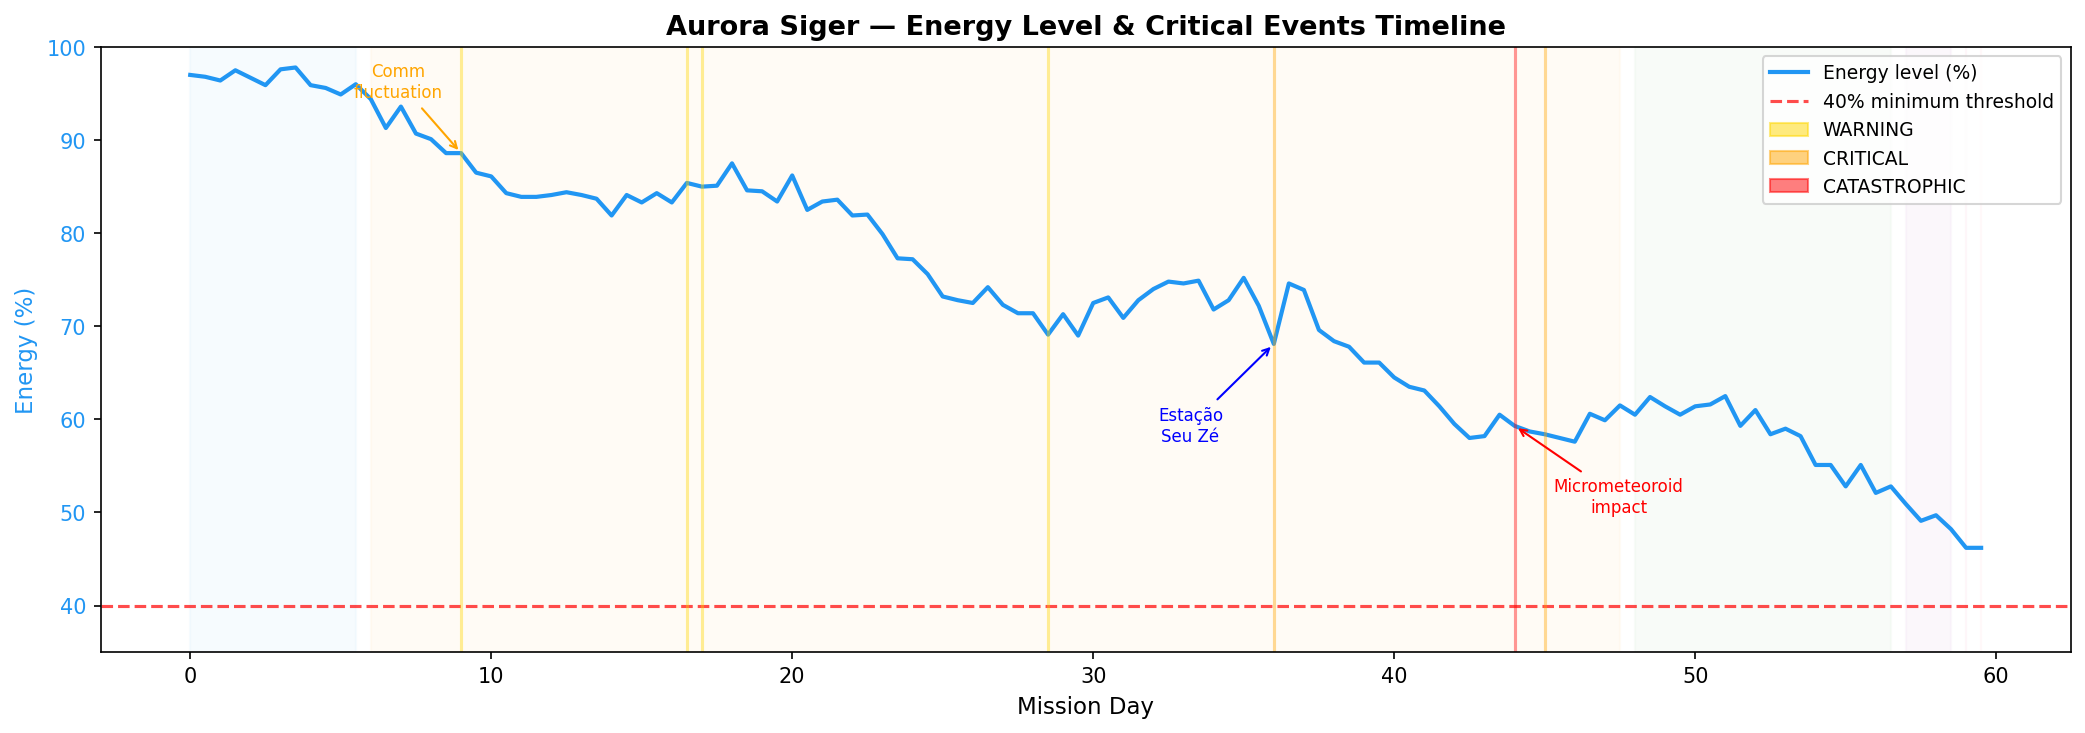

Imagem salva em: h:\dev\FIAP\Aurora-Siger-Mission\imgs\aurora_siger_timeline.png


In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image as IPImage

# Carregar o dataset
df = pd.read_csv('telemetria_nave_spacexg_marte_relatorio.csv')

# Classificar severidade dos alertas (coluna nova)
severidades = []
for alerta in df['overall_alert']:
    if 'Micrometeoroid' in alerta:
        severidades.append('CATASTROPHIC')
    elif 'Navigation' in alerta or 'engine' in alerta:
        severidades.append('CRITICAL')
    elif alerta == 'Nominal':
        severidades.append('NOMINAL')
    else:
        severidades.append('WARNING')

df['severity'] = severidades

# Criar o gráfico
fig, ax1 = plt.subplots(figsize=(14, 5))

# Curva de energia
ax1.plot(df['mission_day'], df['energy_level_pct'], color='#2196F3', linewidth=2, label='Energy level (%)')
ax1.set_xlabel('Mission Day', fontsize=11)
ax1.set_ylabel('Energy (%)', color='#2196F3', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.set_ylim(35, 100)

# Linha de threshold 40%
ax1.axhline(y=40, color='red', linestyle='--', alpha=0.7, label='40% minimum threshold')

# Marcar eventos não-nominais
events = df[df['overall_alert'] != 'Nominal']
for _, row in events.iterrows():
    if row['severity'] == 'CATASTROPHIC':
        color = 'red'
    elif row['severity'] == 'CRITICAL':
        color = 'orange'
    else:
        color = 'gold'
    ax1.axvline(x=row['mission_day'], color=color, alpha=0.4, linestyle='-', linewidth=1.5)

# Anotações dos eventos principais
ax1.annotate('Comm\nfluctuation', xy=(9, df[df['mission_day']==9.0]['energy_level_pct'].values[0]),
            xytext=(-30, 25), textcoords='offset points',
            fontsize=8, ha='center', va='bottom', color='orange',
            arrowprops=dict(arrowstyle='->', color='orange', lw=1))

ax1.annotate('Estação\nSeu Zé', xy=(36, df[df['mission_day']==36.0]['energy_level_pct'].values[0]),
            xytext=(-40, -30), textcoords='offset points',
            fontsize=8, ha='center', va='top', color='blue',
            arrowprops=dict(arrowstyle='->', color='blue', lw=1))

ax1.annotate('Micrometeoroid\nimpact', xy=(44, df[df['mission_day']==44.0]['energy_level_pct'].values[0]),
            xytext=(50, -25), textcoords='offset points',
            fontsize=8, ha='center', va='top', color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1))

# Fundo colorido por fase da missão
phases = df.groupby('phase')['mission_day'].agg(['min', 'max'])
phase_colors = {'Launch & Earth Departure': '#E3F2FD', 'Deep Space Transit': '#FFF3E0',
                'Mars Approach': '#E8F5E9', 'Mars Orbit Insertion': '#F3E5F5',
                'Mars Landing': '#FCE4EC', 'Mars Surface Operations': '#FFEBEE'}
for phase, row in phases.iterrows():
    c = phase_colors.get(phase, '#F5F5F5')
    ax1.axvspan(row['min'], row['max'], alpha=0.3, color=c)

# Legenda
warning_patch = mpatches.Patch(color='gold', alpha=0.5, label='WARNING')
critical_patch = mpatches.Patch(color='orange', alpha=0.5, label='CRITICAL')
catastrophic_patch = mpatches.Patch(color='red', alpha=0.5, label='CATASTROPHIC')
ax1.legend(handles=[ax1.get_lines()[0], ax1.get_lines()[1], warning_patch, critical_patch, catastrophic_patch],
           loc='upper right', fontsize=9)

ax1.set_title('Aurora Siger — Energy Level & Critical Events Timeline', fontsize=13, fontweight='bold')
plt.tight_layout()

# Salvar e exibir
output_path = os.path.join(os.getcwd(), 'imgs', 'aurora_siger_timeline.png')
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.close(fig)

display(IPImage(filename=output_path))
print(f'Imagem salva em: {output_path}')


### Interpretação

Os **80 MWh** gastos na decolagem concentram, em poucos minutos, um consumo equivalente ao de dezenas de residências durante um mês. Em contexto espacial, é apenas terça-feira.

O consumo médio de aproximadamente **116 kW** ao longo do trajeto é compatível com o esperado para uma nave de 73 metros sustentando 6 tripulantes — suporte de vida, controle térmico, navegação, comunicação e propulsão auxiliar operando em paralelo. Para referência, a Estação Espacial Internacional opera com 75–90 kW.

Sem a parada na Estação do Seu Zé no dia 36, a Aurora Siger teria chegado a Marte com cerca de **39,7% de energia**, abaixo do mínimo operacional de 40%. A recarga de ~22,1 MWh na estação foi o que separou a missão de uma crise energética real.

O desvio do asteroide no dia 44 adicionou um custo energético e operacional que não estava previsto. Missões complexas costumam cobrar por imprevistos com juros.

In [16]:
# Automated periodicity detection for communication anomalies

comm_events = df[df['communications_status'] != 'OK']
comm_days = comm_events['mission_day'].values

print("COMMUNICATION ANOMALY PERIODICITY ANALYSIS")
print()
print(f"Communication degradation events: {len(comm_days)}")
print(f"Occurred on days: {', '.join(str(d) for d in comm_days)}")
print()

if len(comm_days) >= 2:
    intervals = []
    for i in range(1, len(comm_days)):
        interval = comm_days[i] - comm_days[i-1]
        intervals.append(interval)
        print(f"  Interval between event {i} and {i+1}: {interval} days")

    avg_interval = sum(intervals) / len(intervals)
    print(f"\n  Average interval: {avg_interval} days")

    # Project next occurrence
    next_predicted = comm_days[-1] + avg_interval
    print(f"  Predicted next occurrence: Day {next_predicted}")

    if next_predicted <= 59.5:
        print(f"  >>> WARNING: predicted event falls WITHIN mission window <<<")
    else:
        print(f"  Next event predicted after mission end (Day 59.5)")

    print()
    print("  Pattern assessment:", end=" ")
    if all(abs(i - avg_interval) < 2 for i in intervals):
        print("REGULAR — consistent interval detected")
        print(f"  Ademar was right. The {avg_interval}-day cycle is not random.")
    else:
        print("IRREGULAR — no consistent periodicity")
else:
    print("  Insufficient data points for periodicity analysis.")

COMMUNICATION ANOMALY PERIODICITY ANALYSIS

Communication degradation events: 3
Occurred on days: 9.0, 28.5, 44.0

  Interval between event 1 and 2: 19.5 days
  Interval between event 2 and 3: 15.5 days

  Average interval: 17.5 days
  Predicted next occurrence: Day 61.5
  Next event predicted after mission end (Day 59.5)

  Pattern assessment: IRREGULAR — no consistent periodicity


## 1.5 Análise Assistida por IA

Com o objetivo de ampliar a interpretação dos dados de telemetria, foi utilizada uma ferramenta de Inteligência Artificial como apoio analítico. O uso da IA não substituiu a leitura técnica dos dados nem a lógica implementada no algoritmo de verificação; sua função foi atuar como recurso complementar para classificar informações, identificar possíveis anomalias e apontar riscos operacionais com base no conjunto de registros observados. Ela não conhece o caderno do Ademar e não resolve o caso do Severino. Ainda assim, foi capaz de identificar padrões relevantes nos dados, apresentados a seguir:

### 1.5.1 O que foi solicitado à IA

A IA recebeu como tarefa interpretar os dados da missão e produzir uma análise qualitativa da telemetria. Em termos práticos, foram solicitados quatro objetivos principais:

- Classificar o comportamento geral da missão, distinguindo períodos de estabilidade e momentos críticos;
- Identificar anomalias relevantes nos registros de temperatura, comunicação, energia, integridade estrutural e status dos módulos críticos;
- Sugerir riscos operacionais, considerando não apenas falhas absolutas, mas também padrões de recorrência e degradações parciais;
- Apoiar a interpretação dos dados para complementar a análise técnica desenvolvida no algoritmo e no script em Python.

### 1.5.2 Prompt utilizado

Para tornar o uso da IA transparente e reproduzível, foi elaborado um prompt com foco técnico e objetivo analítico. O texto utilizado foi o seguinte:

**Prompt enviado à IA:**

> “Analise os dados de telemetria da nave Aurora Siger e produza uma avaliação técnica da missão. Classifique o comportamento geral dos registros, identifique possíveis anomalias, aponte eventos críticos e sugira riscos operacionais. Considere especialmente: temperatura interna e externa, integridade estrutural, nível de energia, pressão dos tanques e status dos módulos críticos. Destaque padrões recorrentes, momentos de maior sensibilidade e impactos operacionais dos eventos detectados. Ao final, apresente uma conclusão sobre a estabilidade geral da missão e sua capacidade de recuperação diante de falhas.”

### 1.5.3 Resposta obtida da IA

A resposta gerada pela IA indicou que a missão apresentou comportamento predominantemente estável, com a maior parte dos registros dentro de faixas esperadas, mas com alguns eventos críticos pontuais de alta relevância operacional.

De forma resumida, os principais pontos identificados foram:

- **Estabilidade geral da missão:** a maior parte da trajetória ocorreu sob condições operacionais normais, sem evidências de falha contínua generalizada;
- **Controle térmico adequado:** mesmo com variações externas, a temperatura interna se manteve controlada, indicando resposta satisfatória do subsistema térmico;
- **Recorrência de falhas de comunicação:** a IA apontou três ocorrências de degradação na comunicação ao longo da missão. Duas delas apareceram como flutuações recorrentes durante o trânsito profundo (dias 9 e 28,5), enquanto a terceira ocorreu associada ao evento estrutural catastrófico do dia 44, o que indica recorrência operacional sem evidência de periodicidade rigorosa;
- **Redução da margem energética:** foi destacada uma queda progressiva na margem de segurança energética, com maior sensibilidade em torno do dia 36, seguida de recuperação posterior;
- **Evento estrutural crítico no dia 44:** a IA classificou esse momento como o mais severo da missão, pois houve comprometimento estrutural simultâneo à degradação de subsistemas críticos;
- **Consequências operacionais posteriores:** foi observada limitação temporária da propulsão após o evento estrutural, indicando que o impacto não ficou restrito a um único registro isolado;
- **Capacidade de recuperação:** apesar dos eventos críticos, a missão demonstrou resiliência e conseguiu restabelecer condições operacionais suficientes para sua continuidade.

### 1.5.4 Como a resposta da IA foi utilizada no projeto

A resposta da IA foi utilizada como apoio interpretativo em três níveis principais do trabalho.

Primeiro, ela ajudou a organizar os eventos por relevância, permitindo diferenciar oscilações normais de ocorrências com maior impacto operacional. Isso foi útil para destacar, por exemplo, que o problema mais importante da missão não foi uma instabilidade contínua, mas sim um conjunto de eventos raros e concentrados em momentos específicos.

Segundo, a IA contribuiu para a identificação de padrões não triviais, como a recorrência das degradações na comunicação sem periodicidade plenamente consistente e a leitura do dia 44 como ponto crítico central da missão. Esses elementos enriqueceram a análise, pois ultrapassam uma verificação puramente binária de “normal” ou “anômalo”.

Terceiro, a resposta foi incorporada à interpretação final dos resultados, reforçando a conclusão de que a missão só foi concluída graças a correções emergenciais e capacidade de adaptação diante de anomalias graves — o que não equivale a uma operação plenamente viável.

### 1.5.5 Interpretação crítica do uso da IA

Embora a IA tenha oferecido contribuições importantes, seu uso neste projeto foi tratado como ferramenta de apoio, e não como fonte autônoma de decisão. As conclusões principais permaneceram fundamentadas nos dados da telemetria, nas faixas seguras definidas no algoritmo e nas verificações implementadas em Python.

Isso é importante porque a IA pode reconhecer padrões e sugerir interpretações úteis, mas sua análise depende da qualidade do prompt, do contexto fornecido e da consistência dos dados disponíveis. Portanto, os resultados gerados por ela precisam sempre ser confrontados com critérios objetivos e com a modelagem técnica do problema.

### 1.5.6 Síntese da análise assistida por IA

Em síntese, a análise assistida por IA permitiu classificar a missão como majoritariamente estável, mas marcada por anomalias pontuais de alto potencial de impacto. A ferramenta foi especialmente útil para destacar a recorrência de falhas de comunicação, embora sem periodicidade estritamente regular, a sensibilidade energética em parte do trajeto e, sobretudo, a gravidade do evento estrutural ocorrido no dia 44.

Dessa forma, a IA agregou valor ao projeto ao oferecer uma leitura qualitativa complementar da telemetria, contribuindo para uma avaliação mais ampla da missão e para uma conclusão mais robusta sobre a capacidade de recuperação da nave Aurora Siger diante de situações críticas.

### 1.5.7 Limitações da análise assistida por IA

É importante destacar que a IA não teve acesso a informações externas à base de telemetria analisada, nem a registros complementares de manutenção, contexto de missão ou histórico técnico aprofundado da nave. Assim, suas conclusões foram produzidas exclusivamente a partir dos dados fornecidos, devendo ser compreendidas como uma análise inferencial assistida, e não como diagnóstico definitivo. Essa limitação reforça a importância de combinar ferramentas inteligentes com validação técnica humana.

---
## 1.6 Reflexão Crítica

### Ética e responsabilidade

O caso do Severino levanta questões que vão além da engenharia. O jetpack falhou, o cabo se soltou e o rastreador parou de responder. Três falhas simultâneas não formam coincidência; formam cadeia de risco.

Quando escrevo `if integridade != 1: registrar falha`, parece apenas lógica computacional. Mas, fora do código, isso significa que alguém saiu para reparar a nave e deixou de ser apenas um nome no crachá para virar uma ausência concreta.

### Impacto social

A SpaceXG lançou a missão a partir da Fazenda Xurupitas, no interior do Tocantins. A comunidade local assistiu à decolagem, mas a pergunta relevante começa quando o espetáculo termina: que tipo de transformação permaneceu no território?

O saldo não é simples. Projetos de grande porte em regiões remotas costumam deixar legado de infraestrutura, mas também podem criar dependência econômica de uma atividade que, por natureza, é intermitente. A pergunta que fica é se a Fazenda Xurupitas terão relevância econômica quando não houver foguete na plataforma.

### Sustentabilidade

A energia caiu de 97% para 46% em 60 dias. Cada manobra custou caro. Cada correção pesou no planejamento. Sem a recarga improvisada do Seu Zé, a missão não teria o mesmo sucesso. Os 340 MWh da Aurora Siger sustentaram 6 tripulantes por 60 dias — mas o reabastecimento emergencial no dia 36 mostrou que a margem entre missão concluída e missão perdida foi de menos de 1% de energia. Projetar sistemas sustentáveis não é apenas escolher fontes limpas; é garantir que a autonomia sobreviva ao plano que deu errado.

No espaço, desperdício se traduz rapidamente em risco. Na Terra, ele costuma ser diluído em prazos longos, cadeias extensas e responsabilidades difusas. O princípio, porém, é o mesmo: sistemas sustentáveis não dependem de abundância, mas de uso disciplinado dos recursos disponíveis.

O Ademar continua ouvindo os sinais. O Severino continua sem memória. E o Seu Zé permanece como uma dessas variáveis que a telemetria não registra, mas que o relatório também não consegue ignorar.

---
## Conclusão

| Verificação | Resultado |
|:---|:---|
| 1.1 Telemetria | 120 leituras; 9 eventos não nominais (8 WARNING + 1 CATASTROPHIC) |
| 1.2 Algoritmo | Pseudocódigo e fluxograma construídos |
| 1.3 Script Python | Verificação automatizada com classificação de severidade (WARNING/CRITICAL/CATASTROPHIC) |
| 1.4 Energia | 340 MWh de capacidade; sem a recarga na Estação do Seu Zé, energia final seria ~39,7% — abaixo do mínimo de 40% |
| 1.5 IA | Riscos mapeados, padrões críticos identificados e recorrência irregular de falhas de comunicação reconhecida |
| 1.6 Reflexão | Discussão sobre ética, impacto social concreto e sustentabilidade |

### Verificação pré-decolagem: **PRONTO PARA DECOLAR**

A fase de lançamento (dias 0 a 5,5) apresentou todas as leituras dentro das faixas seguras. Pelo critério de decolagem, a missão estava apta a partir.

### Avaliação geral da missão: **MISSÃO COMPLETADA COM RESTRIÇÕES CRÍTICAS**

Ao longo dos 60 dias, a missão acumulou 9 leituras fora dos parâmetros seguros, incluindo 1 evento catastrófico (integridade estrutural = 0 no dia 44). A margem energética dependeu de uma recarga não planejada na Estação do Seu Zé; sem ela, a nave teria chegado a Marte abaixo do mínimo operacional. A Aurora Siger completou o trajeto, mas não com a folga que o planejamento previa — completou porque a tripulação soube improvisar quando o planejamento falhou.

---

*Relatório desenvolvido por Marcus Estevan Bandeira — Turma 1CCOB — FIAP, Março de 2026.*
